In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '4'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Load data from Part 1
charging_sessions = pd.read_parquet('intermediate_data/charging_sessions.parquet')

### 4. Clustering

In this section we cluster registered users by their charging behavior using K-Means.

We first filter out sessions without an account, then compute per-session features:
- `duration_hours` -- total time plugged in
- `start_hour` -- fractional hour of day the session began
- `block_time` -- idle time between charging completion and disconnect

These are then aggregated per user into summary statistics (medians and standard deviations), producing the following clustering features: `count`, `start_hour_std`, `start_hour_median`, `median_site`, `median_kwh`, `median_block`, `median_duration`, `median_request`.

**Choosing k:** We use two methods to determine the optimal number of clusters:
1. **Elbow Method** -- plots inertia vs. k; the curve shows no sharp elbow, making this inconclusive on its own.
2. **Silhouette Score** -- peaks at k=3, which we adopt as the final cluster count.

**Cluster Analysis:** We run a full analysis consisting of:
* **PCA Loadings Heatmap** -- shows how each feature loads onto the first three principal components, revealing which features drive separation.
* **Feature Contribution Bar Chart** -- ranks features by their total importance across all components. We tested and removed features which had a low score only keeping those which are currently used
* **Cluster Characterization Profile** -- displays average feature values per cluster as a heatmap, making it easy to interpret and label each cluster.

In [2]:
# Keep only users with accounts and add some useful columns

charging_sessions['has_account'] = charging_sessions['user_id'].notnull().astype(int)
charging_sessions_registered = charging_sessions[charging_sessions["has_account"] == 1].copy()

charging_sessions_registered['duration_hours'] = (
    charging_sessions_registered['disconnect_time'] - charging_sessions_registered['connection_time']
).dt.total_seconds() / 3600


charging_sessions_registered['start_hour'] = charging_sessions_registered['connection_time'].dt.hour + charging_sessions_registered['connection_time'].dt.minute / 60


charging_sessions_registered['done_charging_time'] = charging_sessions_registered['done_charging_time'].fillna(
    charging_sessions_registered['disconnect_time']
)

charging_sessions_registered['block_time'] = (
    charging_sessions_registered['disconnect_time'] - charging_sessions_registered['done_charging_time']
).dt.total_seconds() / 3600


# Group by user and compute aggregated features
charging_sessions_registered_grouped = (
    charging_sessions_registered
        .groupby("user_id")
        .agg(
            count=("start_hour", "count"),             
            start_hour_std=("start_hour", "std"),      
            start_hour_median=("start_hour", "median"),
            median_site=("site_id","median"),
            median_kwh = ('kwh_delivered',"median"),
            median_block = ('block_time',"median"),
            median_duration = ('duration_hours',"median"),
            median_request = ('miles_requested',"median")
        )
        .reset_index()
)

# Replace NaN std values
charging_sessions_registered_grouped["start_hour_std"] = (
    charging_sessions_registered_grouped["start_hour_std"].fillna(0)
)

charging_sessions_registered_grouped

,user_id,count,start_hour_std,start_hour_median,median_site,median_kwh,median_block,median_duration,median_request
0,1.0,1,0.000000,13.183333,2.0,1.659,0.163333,1.404444,10.0
1,17.0,1,0.000000,15.666667,2.0,1.471,0.001944,0.302222,40.0
2,22.0,58,2.219839,8.408333,2.0,17.653,1.191111,5.853056,100.0
3,43.0,1,0.000000,9.200000,2.0,43.266,1.293889,8.282222,200.0
4,45.0,1,0.000000,17.000000,2.0,8.069,1.393889,3.551389,70.0
...,...,...,...,...,...,...,...,...,...
1001,19273.0,3,1.201504,7.466667,1.0,25.040,2.823333,5.840833,100.0
1002,19548.0,3,0.494507,8.766667,1.0,6.196,5.714722,7.814722,50.0
1003,19652.0,1,0.000000,8.116667,1.0,50.536,0.001389,8.227500,200.0
1004,19869.0,1,0.000000,7.866667,2.0,58.354,0.001389,9.421667,200.0


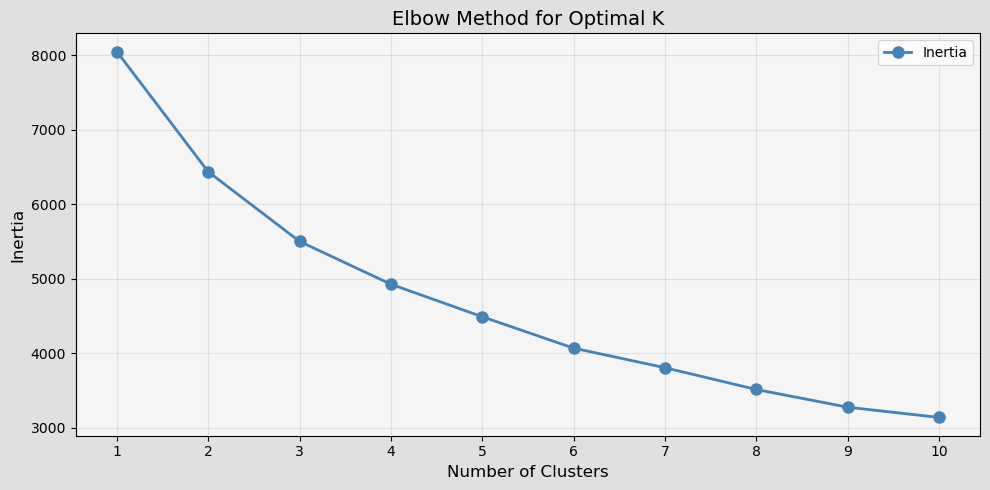

In [3]:
# visualize elbow method for deciding the amount of clusters we should use
def plot_elbow_method(df, feature_cols, max_clusters=10, random_state=42):
    x_raw = df[feature_cols].fillna(0)
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x_raw)
    
    inertia = []
    k_range = range(1, max_clusters + 1)
    
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', random_state=random_state, n_init=10)
        km.fit(x_scaled)
        inertia.append(km.inertia_)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor('#E0E0E0')
    ax.set_facecolor('#F5F5F5')
    
    ax.plot(k_range, inertia, marker='o', linestyle='-', color='steelblue', 
            markersize=8, linewidth=2, label='Inertia')
    
    ax.set_title('Elbow Method for Optimal K', fontsize=14)
    ax.set_xlabel('Number of Clusters', fontsize=12)
    ax.set_ylabel('Inertia', fontsize=12)
    ax.set_xticks(k_range)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

my_features = [
    'count', 'start_hour_std', 'start_hour_median', 'median_site',
    'median_kwh', 'median_block', 'median_duration', 'median_request'
]
plot_elbow_method(charging_sessions_registered_grouped, my_features)

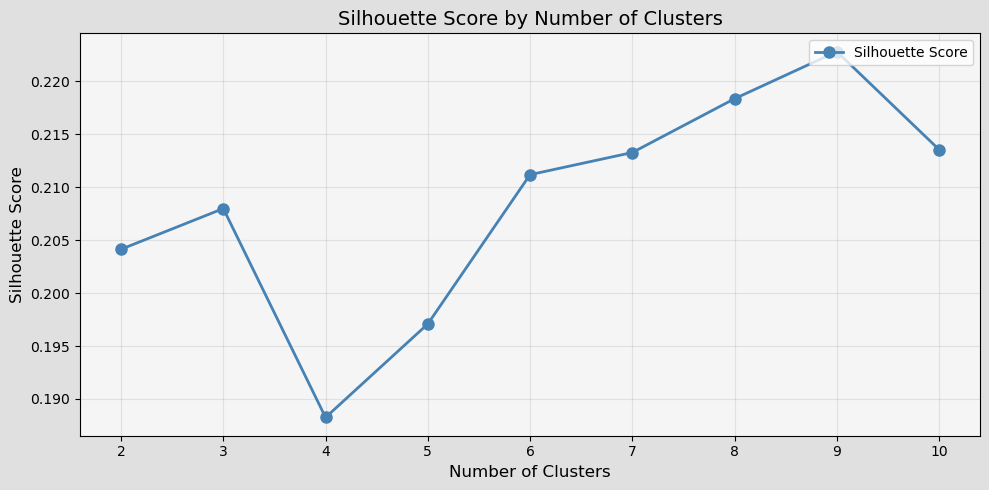

In [4]:
# calclate the silhoutte_score for deciding the amount of clusters we should use, landing at 3

def plot_silhouette_scores(df, feature_cols, max_clusters=10):
    x_scaled = StandardScaler().fit_transform(df[feature_cols].fillna(0))
    scores = []
    k_range = range(2, max_clusters + 1)
    
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        labels = km.fit_predict(x_scaled)
        scores.append(silhouette_score(x_scaled, labels))
    
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor('#E0E0E0')
    ax.set_facecolor('#F5F5F5')
    
    ax.plot(k_range, scores, marker='o', linestyle='-', color='steelblue', 
            markersize=8, linewidth=2, label='Silhouette Score')
    

    
    ax.set_title('Silhouette Score by Number of Clusters', fontsize=14)
    ax.set_xlabel('Number of Clusters', fontsize=12)
    ax.set_ylabel('Silhouette Score', fontsize=12)
    ax.set_xticks(k_range)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

plot_silhouette_scores(charging_sessions_registered_grouped, my_features)

In [5]:
# Calculates Feature Importance via PCA Loadings to identify key features,
# followed by K-Means++ clustering on standardized raw data. Provides visual
# diagnostics of feature contributions and a detailed Cluster Characterization
# Profile based on average values across all dimensions.

def run_full_cluster_analysis(df, feature_cols, n_clusters=3, random_state=42):
    # Data Preparation
    x_raw = df[feature_cols].fillna(0)
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x_raw)

    # PCA & K-Means++
    pca = PCA(n_components=3)
    pca.fit(x_scaled) # Fitting PCA to get loadings

    kmeans = KMeans(
        n_clusters=n_clusters,
        init='k-means++',
        random_state=random_state,
        n_init=10
    )
    clusters = kmeans.fit_predict(x_scaled)

    # PCA Loadings Heatmap
    loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2', 'PC3'], index=feature_cols)
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('#E0E0E0')
    # cbar=False removes the color scale bar from the right
    sns.heatmap(loadings, annot=True, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_title('PCA Loadings: Feature Correlation Per Component', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Feature Contribution Bar Chart
    contribution = loadings.abs().sum(axis=1).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(12, 4))
    fig.patch.set_facecolor('#E0E0E0')
    ax.set_facecolor('#F5F5F5')
    contribution.plot(kind='bar', color='steelblue', edgecolor='navy', ax=ax)
    ax.set_title('Total Feature Contribution Score', fontsize=14)
    ax.set_ylabel('Aggregate Importance', fontsize=12)
    ax.set_xlabel('Feature', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Cluster Characterization Profile
    profile_df = df.copy()
    profile_df['Cluster'] = clusters
    cluster_summary = profile_df.groupby('Cluster')[feature_cols].mean()

    # Standardizing for visualization contrast
    summary_std = (cluster_summary - cluster_summary.mean()) / cluster_summary.std()

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor('#E0E0E0')
    # cbar=False removes the color scale bar from the right
    sns.heatmap(summary_std, annot=cluster_summary, fmt=".2f",
                cmap="RdYlGn", center=0, vmin=-2, vmax=2, linewidths=1, ax=ax, cbar=False)
    ax.set_title('Cluster Characterization Profile (Average Feature Values)', fontsize=14)
    ax.set_xlabel('Feature', fontsize=12)
    ax.set_ylabel('Cluster', fontsize=12)
    plt.tight_layout()
    plt.show()

    return profile_df

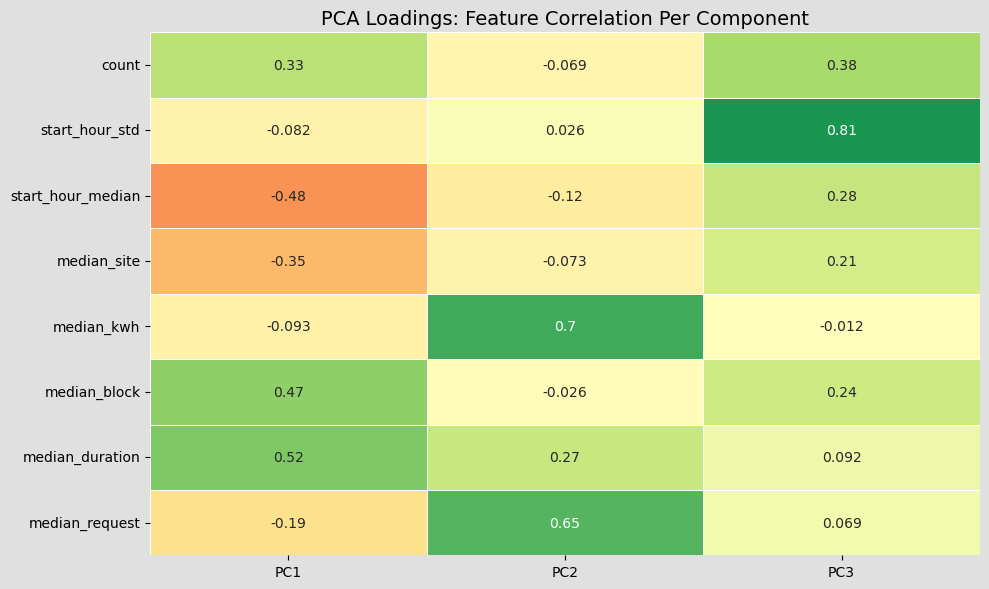

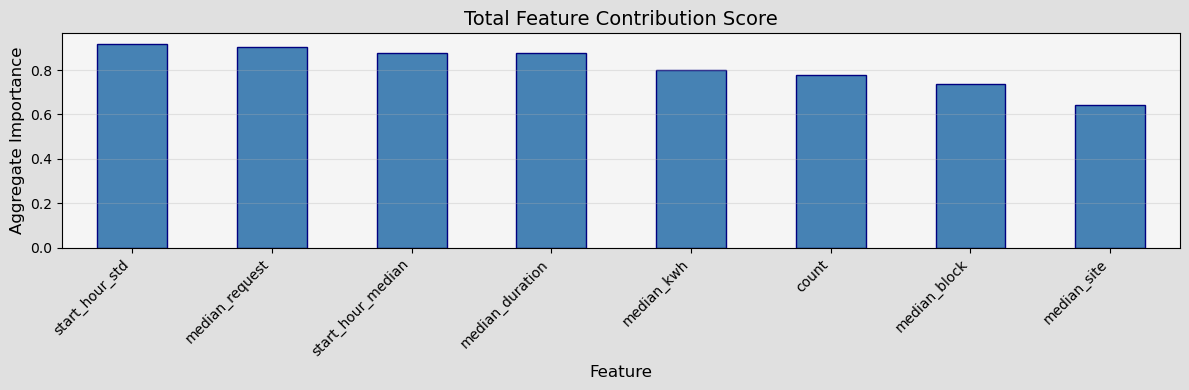

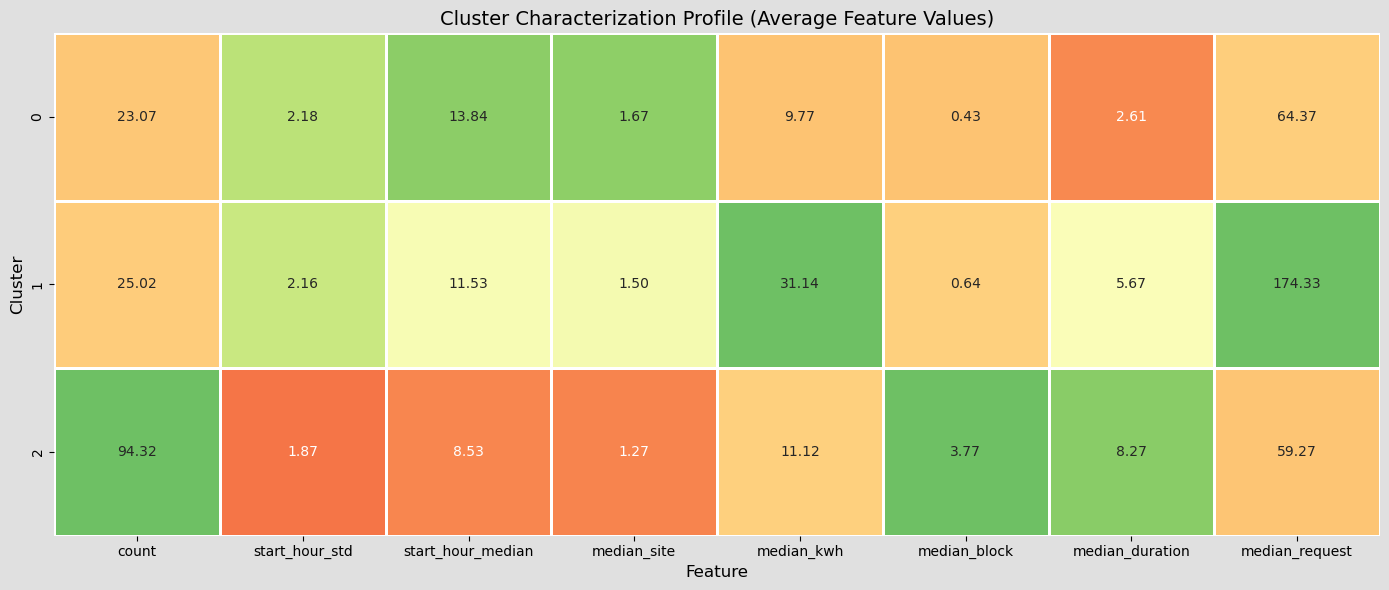

In [6]:

my_features = [
    'count', 'start_hour_std', 'start_hour_median', 'median_site',
    'median_kwh', 'median_block', 'median_duration', 'median_request'
]

results_df = run_full_cluster_analysis(
    df=charging_sessions_registered_grouped, 
    feature_cols=my_features, 
    n_clusters=3
)